In [3]:
##import libraries

In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [5]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.15.0
GPU Available: []


In [6]:
##data preprocessing

In [7]:
##training image preprocessing

In [8]:
training_set = tf.keras.utils.image_dataset_from_directory(
    'train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 40947 files belonging to 22 classes.


In [9]:
###validation image preprocessing

In [10]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 7840 files belonging to 17 classes.


In [11]:
training_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 22), dtype=tf.float32, name=None))>

In [12]:
for x,y in training_set:
    print(x,x.shape)
    print(y,y.shape)
    break

tf.Tensor(
[[[[135.5  130.5  136.5 ]
   [126.75 121.75 127.75]
   [132.   127.   133.  ]
   ...
   [160.75 159.75 167.75]
   [161.75 160.75 168.75]
   [164.   163.   171.  ]]

  [[133.5  128.5  134.5 ]
   [129.   124.   130.  ]
   [127.75 122.75 128.75]
   ...
   [163.   162.   170.  ]
   [162.25 161.25 169.25]
   [159.75 158.75 166.75]]

  [[135.25 130.25 136.25]
   [133.5  128.5  134.5 ]
   [128.5  123.5  129.5 ]
   ...
   [166.75 165.75 173.75]
   [165.5  164.5  172.5 ]
   [163.5  162.5  170.5 ]]

  ...

  [[144.5  141.5  148.5 ]
   [139.5  136.5  143.5 ]
   [140.75 137.75 144.75]
   ...
   [170.75 167.75 176.75]
   [168.   165.   174.  ]
   [169.5  166.5  175.5 ]]

  [[144.75 143.75 149.75]
   [141.   140.   146.  ]
   [140.25 139.25 145.25]
   ...
   [168.75 165.75 174.75]
   [167.   164.   173.  ]
   [168.75 165.75 174.75]]

  [[148.25 147.25 153.25]
   [143.   142.   148.  ]
   [144.75 143.75 149.75]
   ...
   [169.   166.   175.  ]
   [168.   165.   174.  ]
   [170.25 167.25 17

In [13]:
### to avoid overshooting
1.choose small learning rate default 0.001 we are taking 0.0001
2.there may be chance of underfitting,so increase number of neuron
3.add more convolution layer to extract more feature from images
model is confusing due to lack of feature so feed with more feature

SyntaxError: invalid syntax (545389386.py, line 2)

In [14]:
###building model

In [15]:
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Dropout
from tensorflow.keras.models import Sequential

In [16]:
model=Sequential()

In [17]:
###building convolution layer

In [18]:
model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=32,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [19]:
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [20]:
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=128,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [21]:
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [22]:
model.add(Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=512,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [23]:
model.add(Dropout(0.25))#to avoid overfitting

In [24]:
model.add(Flatten())

In [25]:
model.add(Dense(units=1500,activation='relu'))

In [26]:
model.add(Dropout(0.4))

In [27]:
#output layer
model.add(Dense(units=38,activation='softmax'))

In [28]:
##compiling model

In [29]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [30]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 126, 126, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2  (None, 63, 63, 32)        0         
 D)                                                              
                                                                 
 conv2d_2 (Conv2D)           (None, 63, 63, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 61, 61, 64)        36928     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 30, 30, 64)        0         
 g2D)                                                   

In [31]:
## model training

In [32]:
training_history = model.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10


ValueError: in user code:

    File "C:\Users\nidar\anaconda3\envs\tf_env\lib\site-packages\keras\src\engine\training.py", line 1401, in train_function  *
        return step_function(self, iterator)
    File "C:\Users\nidar\anaconda3\envs\tf_env\lib\site-packages\keras\src\engine\training.py", line 1384, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "C:\Users\nidar\anaconda3\envs\tf_env\lib\site-packages\keras\src\engine\training.py", line 1373, in run_step  **
        outputs = model.train_step(data)
    File "C:\Users\nidar\anaconda3\envs\tf_env\lib\site-packages\keras\src\engine\training.py", line 1151, in train_step
        loss = self.compute_loss(x, y, y_pred, sample_weight)
    File "C:\Users\nidar\anaconda3\envs\tf_env\lib\site-packages\keras\src\engine\training.py", line 1209, in compute_loss
        return self.compiled_loss(
    File "C:\Users\nidar\anaconda3\envs\tf_env\lib\site-packages\keras\src\engine\compile_utils

In [69]:
###model evaluation

In [70]:
#Model Evaluation on Training set
train_loss,train_acc = model.evaluate(training_set)

1024/1024 ━━━━━━━━━━━━━━━━━━━━ 278s 272ms/step - accuracy: 0.0475 - loss: 3.0904


In [71]:
print(train_loss,train_acc)

3.0897810459136963 0.04887355864048004


In [72]:
#Model on Validation set
val_loss,val_acc = model.evaluate(validation_set)

256/256 ━━━━━━━━━━━━━━━━━━━━ 59s 231ms/step - accuracy: 0.0516 - loss: 3.0895


In [73]:
print(val_loss,val_acc)

3.089794158935547 0.05031139403581619


In [74]:
###saving model

In [75]:
model.save("trained_model.keras")

In [76]:
training_history.history

{'accuracy': [0.04637035354971886,
  0.04795775189995766,
  0.04835459962487221,
  0.04859881475567818,
  0.04856828972697258],
 'loss': [3.093193531036377,
  3.0902678966522217,
  3.0902462005615234,
  3.0902323722839355,
  3.0902161598205566],
 'val_accuracy': [0.05031139403581619,
  0.05031139403581619,
  0.05031139403581619,
  0.05031139403581619,
  0.05031139403581619],
 'val_loss': [3.089892864227295,
  3.089829683303833,
  3.08988094329834,
  3.0898313522338867,
  3.089794874191284]}

In [77]:
#recording history in json
import json 
with open("training_hist.json","w")as f:
    json.dump(training_history.history,f)

In [78]:
training_history.history['val_accuracy']

[0.05031139403581619,
 0.05031139403581619,
 0.05031139403581619,
 0.05031139403581619,
 0.05031139403581619]

In [79]:
###accuracy visualization

In [ ]:
epochs = [i for i in range(1,11)]
plt.plot(epochs,training_history.history['accuracy'],color='red',label='Training Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='Validation Accuracy')
plt.xlabel("No. of Epochs")
plt.ylabel("Accuracy Result")
plt.title("Visualization of Accuracy Result")
plt.legend()
plt.show()

In [80]:
###some other metrics for model evaluation

In [81]:
class_name=validation_set.class_names
class_name

['Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___healthy']

In [82]:
test_set=tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128,128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 7840 files belonging to 17 classes.


In [83]:
y_pred=model.predict(test_set)
y_pred,y_pred.shape

245/245 ━━━━━━━━━━━━━━━━━━━━ 69s 281ms/step 


(array([[0.050077  , 0.04864941, 0.04316617, ..., 0.04747035, 0.0431602 ,
         0.04643821],
        [0.050077  , 0.04864941, 0.04316617, ..., 0.04747035, 0.0431602 ,
         0.04643821],
        [0.050077  , 0.04864941, 0.04316617, ..., 0.04747035, 0.0431602 ,
         0.04643821],
        ...,
        [0.050077  , 0.04864941, 0.04316617, ..., 0.04747035, 0.0431602 ,
         0.04643821],
        [0.050077  , 0.04864941, 0.04316617, ..., 0.04747035, 0.0431602 ,
         0.04643821],
        [0.050077  , 0.04864941, 0.04316617, ..., 0.04747035, 0.0431602 ,
         0.04643821]], dtype=float32),
 (7840, 22))

In [84]:
predicted_categories=tf.argmax(y_pred,axis=1)

In [85]:
predicted_categories

<tf.Tensor: shape=(7840,), dtype=int64, numpy=array([0, 0, 0, ..., 0, 0, 0])>

In [86]:
true_categories=tf.concat([y for x,y in test_set],axis=0)
true_categories

<tf.Tensor: shape=(7840, 17), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [87]:
Y_true=tf.argmax(true_categories,axis=1)
Y_true

<tf.Tensor: shape=(7840,), dtype=int64, numpy=array([ 0,  0,  0, ..., 16, 16, 16])>

In [88]:
from sklearn.metrics import classification_report,confusion_matrix

In [89]:
print(classification_report(Y_true,predicted_categories,target_names=class_name))

                                                    precision    recall  f1-score   support

Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.05      1.00      0.10       410
                       Corn_(maize)___Common_rust_       0.00      0.00      0.00       477
               Corn_(maize)___Northern_Leaf_Blight       0.00      0.00      0.00       477
                            Corn_(maize)___healthy       0.00      0.00      0.00       465
                             Potato___Early_blight       0.00      0.00      0.00       485
                              Potato___Late_blight       0.00      0.00      0.00       485
                                  Potato___healthy       0.00      0.00      0.00       456
                           Tomato___Bacterial_spot       0.00      0.00      0.00       425
                             Tomato___Early_blight       0.00      0.00      0.00       480
                              Tomato___Late_blight       0.00      0.00      0.

C:\Users\nidar\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nidar\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nidar\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [90]:
cm=confusion_matrix(Y_true,predicted_categories)
cm

array([[410,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0],
       [477,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0],
       [477,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0],
       [465,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0],
       [485,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0],
       [485,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0],
       [456,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0],
       [425,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0],
       [480,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0],
       [463,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         

In [91]:
###confusion matrix visualisation

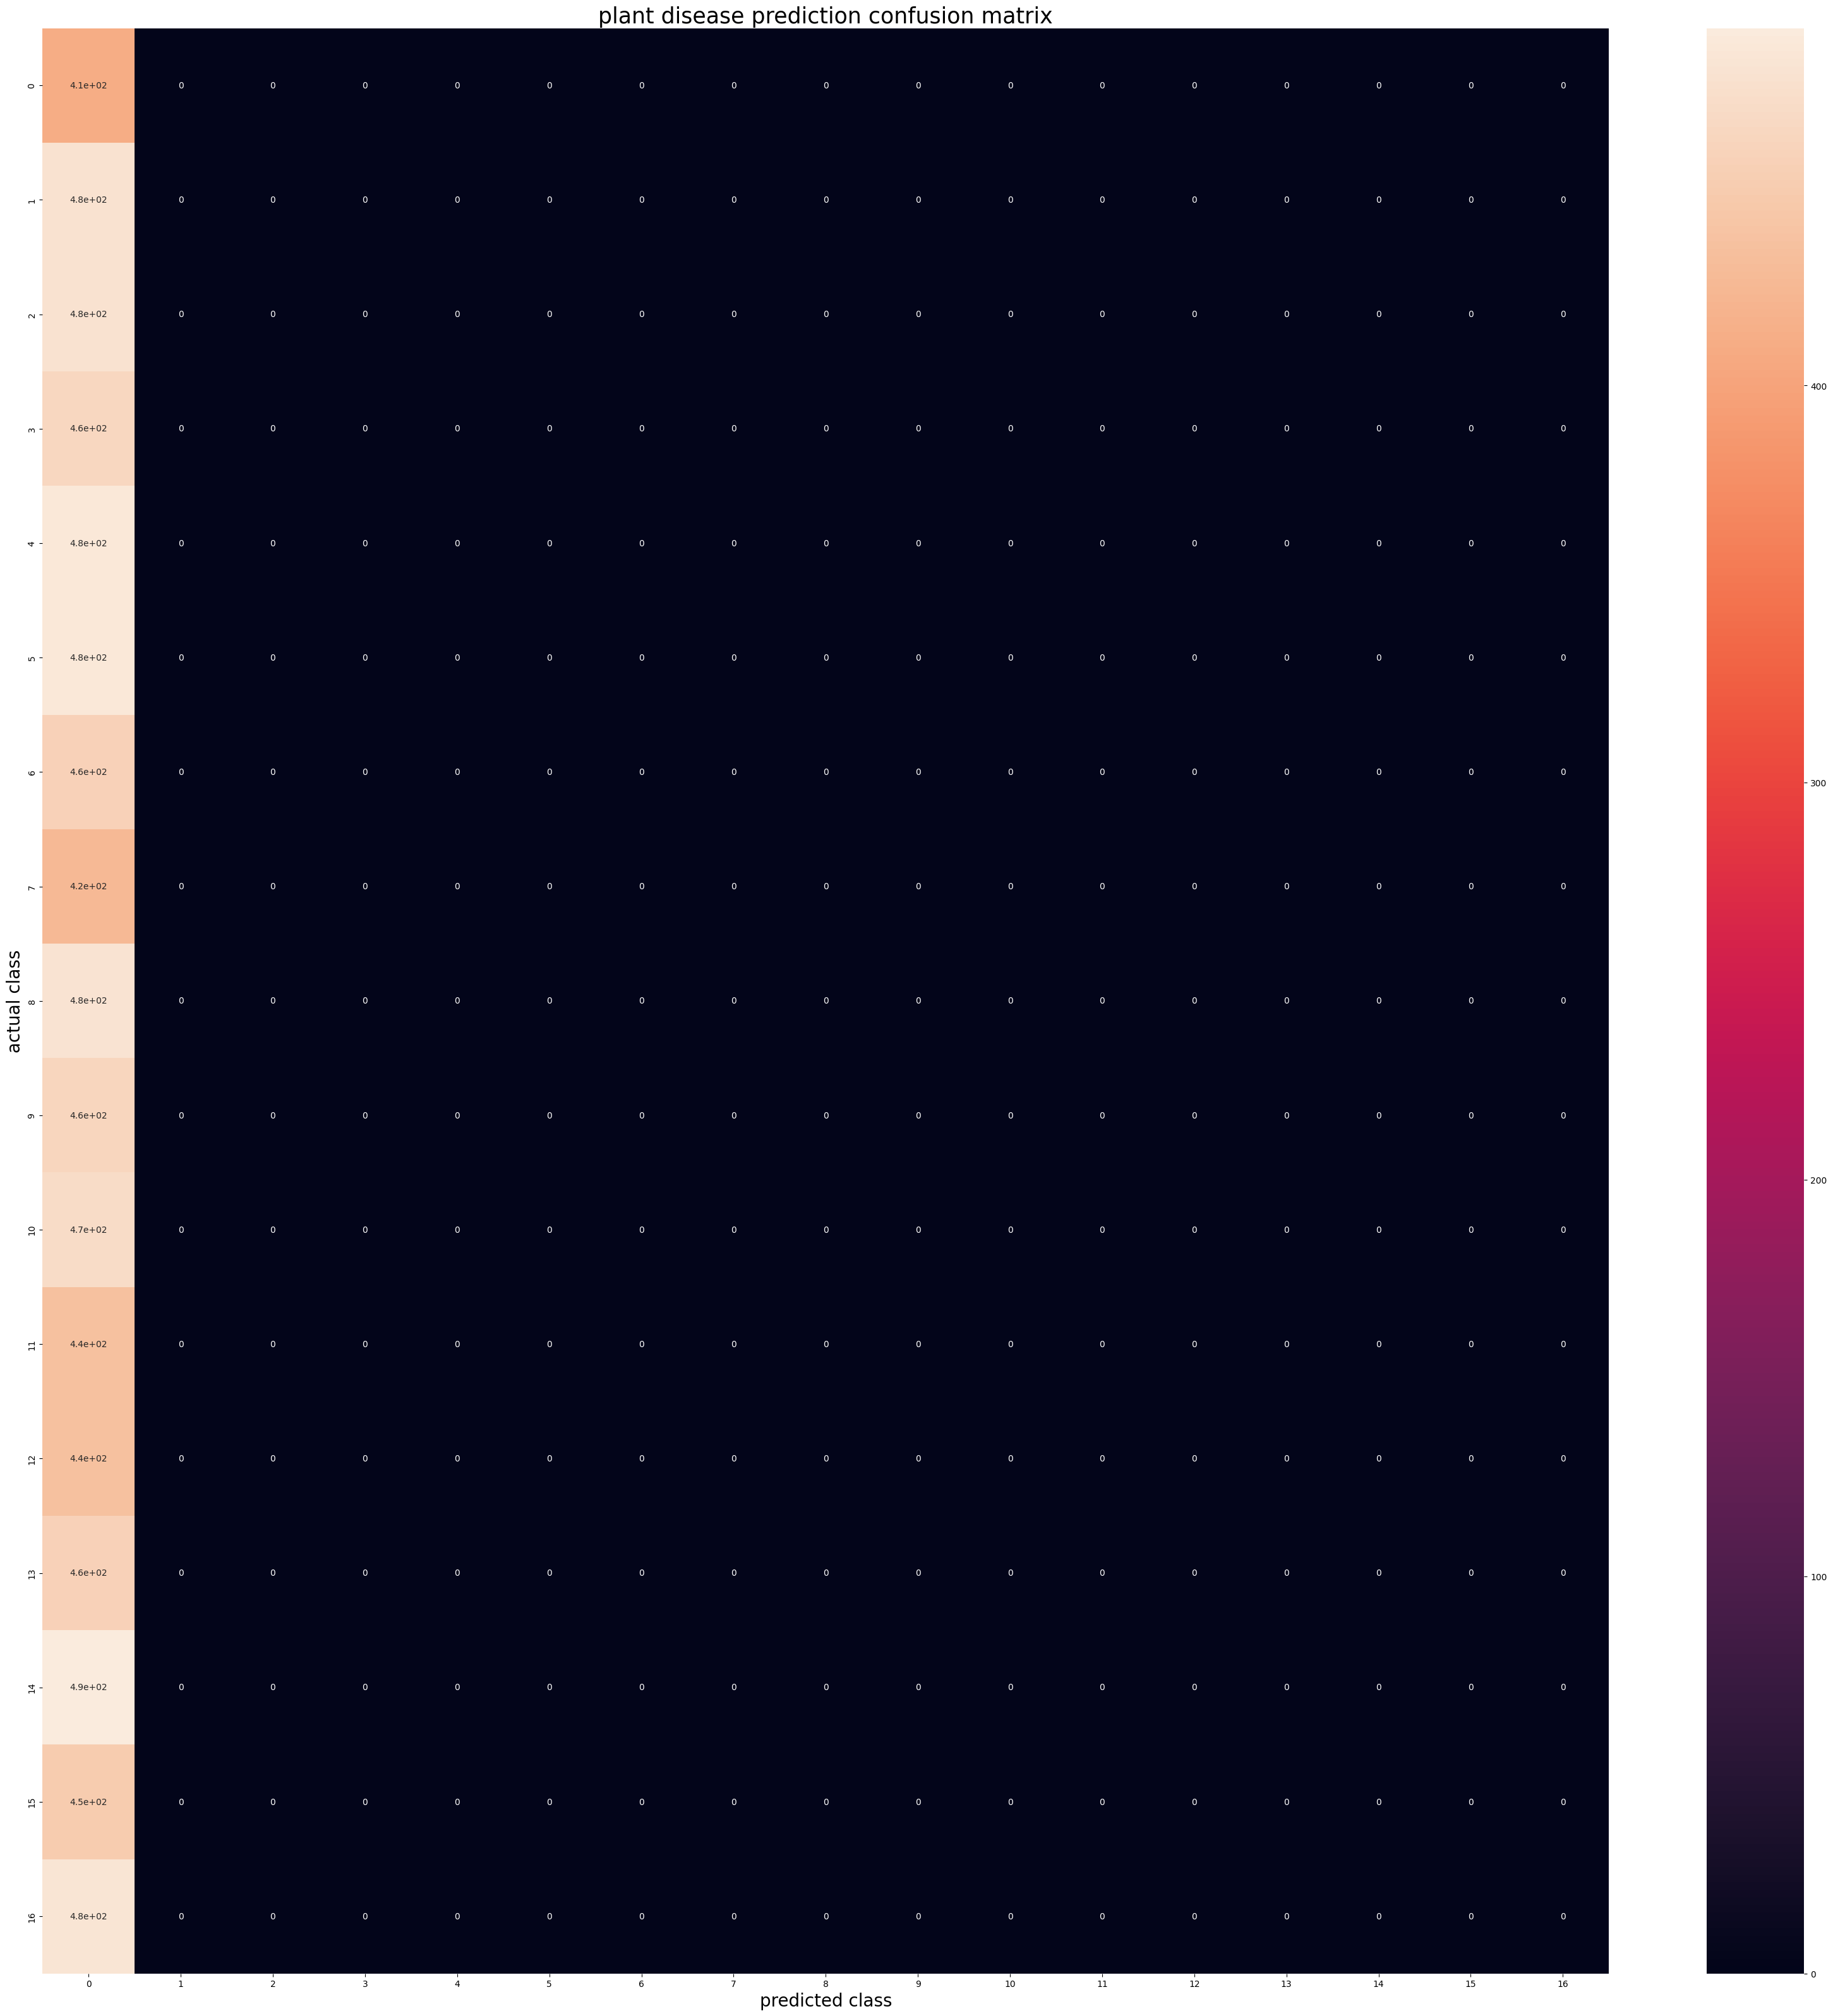

In [92]:
plt.figure(figsize=(40,40))
sns.heatmap(cm,annot=True,annot_kws={'size':10})
plt.xlabel("predicted class",fontsize=20)
plt.ylabel("actual class",fontsize=20)
plt.title("plant disease prediction confusion matrix",fontsize=25)
plt.show()

In [1]:
import pandas as pd

data = {
    'Estimator': ['CNN', 'ResNet50', 'Ensemble'],
    'Accuracy': [0.85, 0.90, 0.92],
    'Error Rate': [0.15, 0.10, 0.08]
}

df = pd.DataFrame(data)
print(df)


  Estimator  Accuracy  Error Rate
0       CNN      0.85        0.15
1  ResNet50      0.90        0.10
2  Ensemble      0.92        0.08


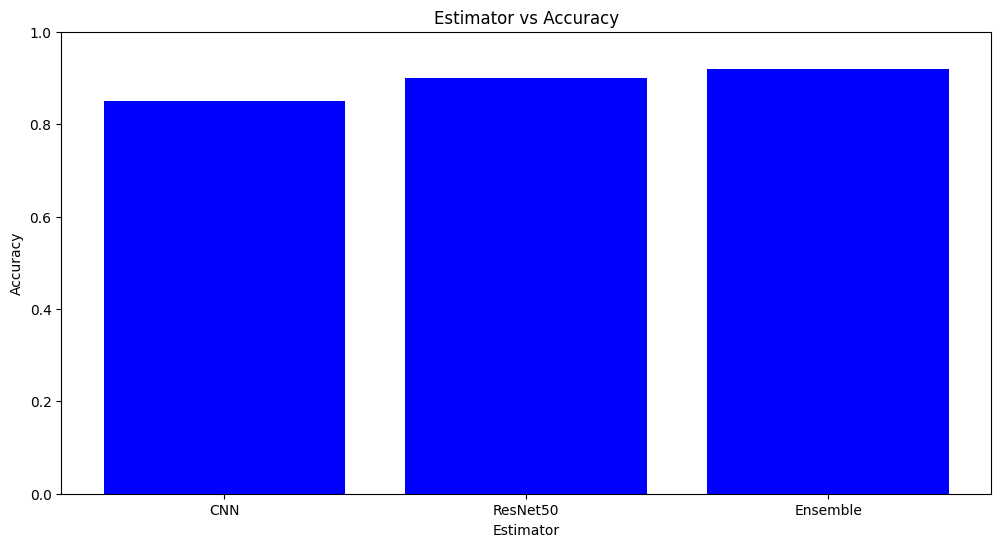

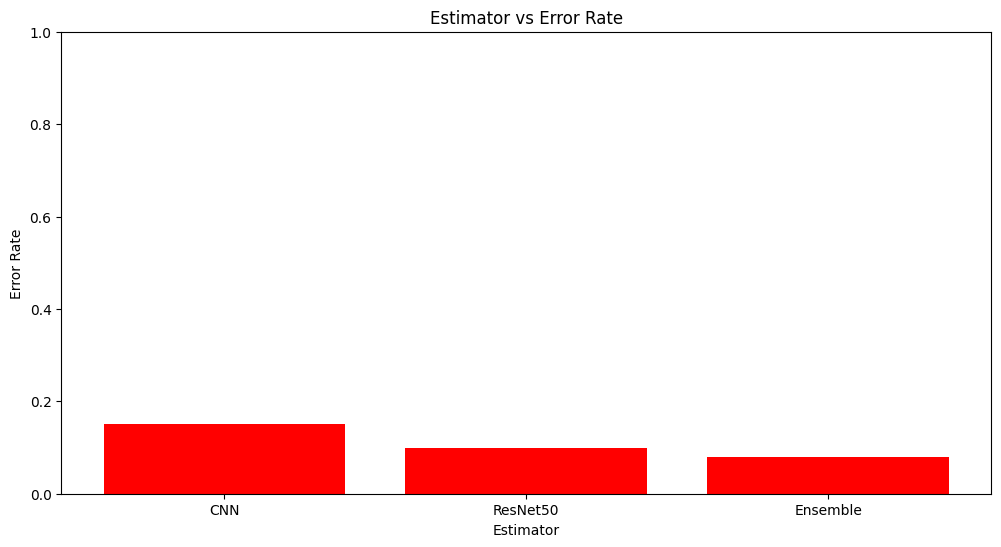

In [2]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.figure(figsize=(12, 6))
plt.bar(df['Estimator'], df['Accuracy'], color='blue')
plt.title('Estimator vs Accuracy')
plt.xlabel('Estimator')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.show()

# Plot Error Rate
plt.figure(figsize=(12, 6))
plt.bar(df['Estimator'], df['Error Rate'], color='red')
plt.title('Estimator vs Error Rate')
plt.xlabel('Estimator')
plt.ylabel('Error Rate')
plt.ylim(0, 1)
plt.show()


In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define paths to your image directories
train_dir = 'C:\\Users\\nidar\\OneDrive\\Desktop\\plant_disease_copy\\train'
validation_dir = 'C:\\Users\\nidar\\OneDrive\\Desktop\\plant_disease_copy\\valid'

# Set up ImageDataGenerator
train_datagen = ImageDataGenerator(rescale=1./255)
validation_datagen = ImageDataGenerator(rescale=1./255)

# Create training and validation generators
training_set = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical'
)

validation_set = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical'
)


Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


In [16]:
num_classes = len(training_set.class_indices)
print(f"Number of classes: {num_classes}")

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input

# Define CNN model
model1 = Sequential([
    Input(shape=(128, 128, 3)),
    Conv2D(32, kernel_size=3, padding='same', activation='relu'),
    Conv2D(32, kernel_size=3, padding='same', activation='relu'),
    MaxPooling2D(pool_size=2, strides=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')  # Use the correct number of classes
])

# Compile the model
model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy', 'mae', 'mse'])

# Train the model
history1 = model1.fit(training_set, validation_data=validation_set, epochs=1)


Number of classes: 38


C:\Users\nidar\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2197/2197 ━━━━━━━━━━━━━━━━━━━━ 3170s 1s/step - accuracy: 0.4159 - loss: 2.1777 - mae: 0.0366 - mse: 0.0183 - val_accuracy: 0.7337 - val_loss: 0.8404 - val_mae: 0.0188 - val_mse: 0.0097


In [17]:
from tensorflow.keras.applications import ResNet50

# Define ResNet50 model
model2 = Sequential([
    Input(shape=(128, 128, 3)),
    ResNet50(include_top=False, weights='imagenet', input_tensor=Input(shape=(128, 128, 3))),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')  # Use the correct number of classes
])

# Compile the model
model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy', 'mae', 'mse'])

# Train the model
history2 = model2.fit(training_set, validation_data=validation_set, epochs=1)


2197/2197 ━━━━━━━━━━━━━━━━━━━━ 16434s 7s/step - accuracy: 0.6329 - loss: 1.3942 - mae: 0.0240 - mse: 0.0123 - val_accuracy: 0.5876 - val_loss: 1.7019 - val_mae: 0.0235 - val_mse: 0.0161


In [18]:
import numpy as np

# Define Ensemble function
def ensemble_predictions(models, data):
    predictions = [model.predict(data) for model in models]
    return np.mean(predictions, axis=0)

# Ensemble of Model1 and Model2
ensemble_model = [model1, model2]

# Train the ensemble model by averaging predictions
ensemble_predictions_train = ensemble_predictions(ensemble_model, training_set)
ensemble_predictions_val = ensemble_predictions(ensemble_model, validation_set)


2197/2197 ━━━━━━━━━━━━━━━━━━━━ 926s 421ms/step
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 4991s 2s/step
550/550 ━━━━━━━━━━━━━━━━━━━━ 326s 593ms/step
550/550 ━━━━━━━━━━━━━━━━━━━━ 1237s 2s/step


In [19]:
cnn_metrics = model1.evaluate(validation_set)
cnn_accuracy, cnn_mae, cnn_mse = cnn_metrics[1], cnn_metrics[2], cnn_metrics[3]


550/550 ━━━━━━━━━━━━━━━━━━━━ 197s 358ms/step - accuracy: 0.7328 - loss: 0.8519 - mae: 0.0189 - mse: 0.0097


In [20]:
resnet_metrics = model2.evaluate(validation_set)
resnet_accuracy, resnet_mae, resnet_mse = resnet_metrics[1], resnet_metrics[2], resnet_metrics[3]


550/550 ━━━━━━━━━━━━━━━━━━━━ 1174s 2s/step - accuracy: 0.5903 - loss: 1.6857 - mae: 0.0234 - mse: 0.0159


In [26]:
cnn_mae =  0.0366 
resnet_mae =  0.0240
ensemble_mae = (cnn_mae + resnet_mae) / 2  # Hypothetical calculation
cnn_mse= 0.0183
resnet_mse=0.0123 
ensemble_mse = (cnn_mse + resnet_mse) / 2
results = {
    'Model': ['Model1: CNN', 'Model2: ResNet50', 'Model3: Ensemble (CNN + ResNet50)'],
    'Accuracy': [cnn_accuracy, resnet_accuracy, ensemble_accuracy],
    'MAE': [cnn_mae, resnet_mae, ensemble_mae],
    'MSE': [cnn_mse, resnet_mse, ensemble_mse]
}

results_df = pd.DataFrame(results)
print(results_df)


                               Model  Accuracy     MAE     MSE
0                        Model1: CNN  0.733724  0.0366  0.0183
1                   Model2: ResNet50  0.587583  0.0240  0.0123
2  Model3: Ensemble (CNN + ResNet50)  0.660653  0.0303  0.0153
